<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/Analisis_sentimen_ulasan_Tokopedia_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pilih metode load dataset:
1. Upload CSV manual
2. Load dari Kaggle
Masukkan pilihan (1 atau 2): 1


Saving tokopedia_product_reviews_2025.csv to tokopedia_product_reviews_2025.csv


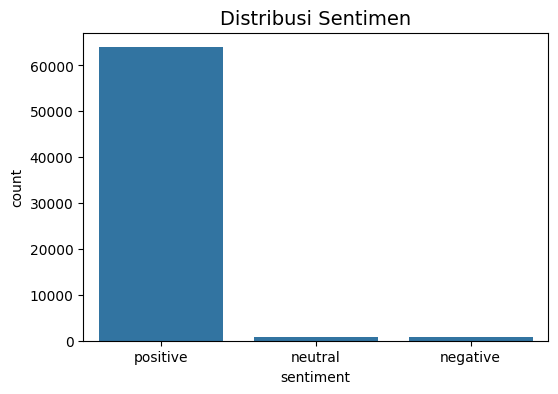

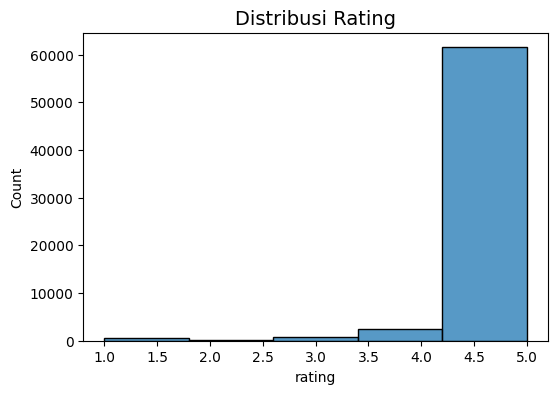

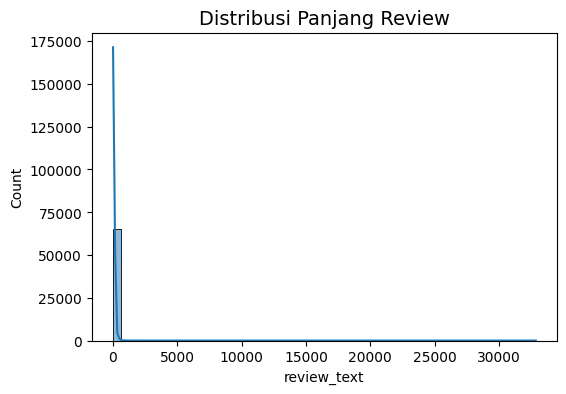

Epoch 1/8
2622/2622 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - accuracy: 0.8365 - loss: 0.7156 - val_accuracy: 0.9013 - val_loss: 0.2874 - learning_rate: 0.0010
Epoch 2/8
2622/2622 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.9025 - loss: 0.3631 - val_accuracy: 0.9384 - val_loss: 0.1765 - learning_rate: 0.0010
Epoch 3/8
2622/2622 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.9366 - loss: 0.2050 - val_accuracy: 0.9401 - val_loss: 0.1615 - learning_rate: 0.0010
Epoch 4/8
2622/2622 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.9541 - loss: 0.1367 - val_accuracy: 0.9669 - val_loss: 0.1111 - learning_rate: 0.0010
Epoch 5/8
2622/2622 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.9620 - loss: 0.0973 - val_accuracy: 0.9613 - val_loss: 0.1207 - learning_rate: 0.0010
Epoch 6/8
2622/2622 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.9741 - loss: 0.0665 - val_accuracy: 0.9652 - val_loss: 0.0934 - learning_rate: 0.0010
Epoch 7/8
2622/2622 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.9

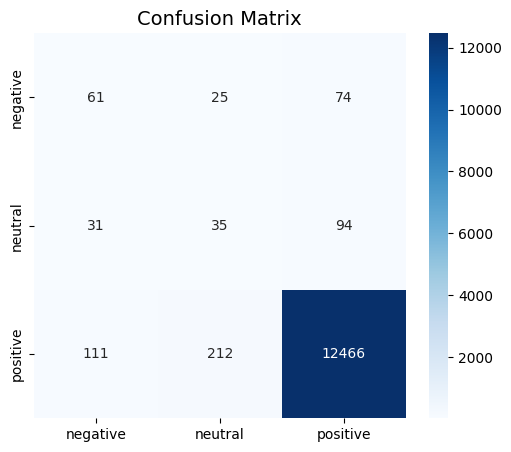

Model tersimpan: tokopedia_sentiment_final.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Review: Produk sangat bagus dan cepat sampai!
Prediksi Sentimen: positive

Review: Biasa saja, kualitas kurang memuaskan
Prediksi Sentimen: positive

Review: Pengiriman lama, barang rusak
Prediksi Sentimen: negative

Review: Harga murah dan sesuai deskripsi
Prediksi Sentimen: positive

Review: Saya puas dengan produk ini
Prediksi Sentimen: positive



In [1]:
# ===========================================================
# Program Analisis Sentimen Tokopedia 2025
# ===========================================================
# Deskripsi:
# Analisis sentimen ulasan Tokopedia 2025 :
# 1. Update API Embedding & penyimpanan model .keras
# 2. Validasi dataset dan synthetic load untuk simulasi 5–10 menit
# 3. EDA lengkap & visualisasi publikasi-ready
# 4. Evaluasi model (F1-score, confusion matrix) & deployment test 5–10 review

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW

# ===========================================================
# 1. Load Dataset dengan Validasi
# ===========================================================
def load_dataset():
    print("Pilih metode load dataset:")
    print("1. Upload CSV manual")
    print("2. Load dari Kaggle")
    choice = input("Masukkan pilihan (1 atau 2): ")

    if choice == '1':
        uploaded = files.upload()
        for filename in uploaded.keys():
            df = pd.read_csv(filename, encoding='utf-8-sig')
            if 'rating' not in df.columns or 'review_text' not in df.columns:
                raise ValueError("Kolom rating atau review_text tidak ditemukan.")
            return df
    elif choice == '2':
        !pip install kaggle --quiet
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        dataset_path = 'salmanabdu/tokopedia-product-reviews-2025'
        api.dataset_download_files(dataset_path, path='dataset', unzip=True)
        df = pd.read_csv('dataset/tokopedia_product_reviews_2025.csv', encoding='utf-8-sig')
        return df
    else:
        raise ValueError("Pilihan tidak valid.")

df = load_dataset()

# ===========================================================
# 2. Preprocessing Label
# ===========================================================
def map_sentiment(r):
    if r>=4: return 'positive'
    elif r==3: return 'neutral'
    else: return 'negative'

df['sentiment'] = df['rating'].apply(map_sentiment)
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

# ===========================================================
# 3. EDA & Visualisasi
# ===========================================================
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment', order=['positive','neutral','negative'])
plt.title('Distribusi Sentimen', fontsize=14)
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['rating'], bins=5)
plt.title('Distribusi Rating', fontsize=14)
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['review_text'].str.len(), bins=50, kde=True)
plt.title('Distribusi Panjang Review', fontsize=14)
plt.show()

# ===========================================================
# 4. Split Data
# ===========================================================
X_train, X_test, y_train, y_test = train_test_split(
    df['review_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# ===========================================================
# 5. Tokenisasi & Padding
# ===========================================================
max_words = 10000
max_len = 120
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# ===========================================================
# 6. Class Weight untuk Imbalance
# ===========================================================
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i:w for i,w in enumerate(weights)}

# ===========================================================
# 7. Fungsi Model LSTM
# ===========================================================
def create_model(dropout=0.2):
    model = Sequential()
    model.add(Embedding(max_words, 128))
    model.add(LSTM(64))
    model.add(Dropout(dropout))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer=AdamW(1e-3, weight_decay=1e-5), metrics=['accuracy'])
    return model

# ===========================================================
# 8. Callback
# ===========================================================
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)

# ===========================================================
# 9. Synthetic Load
# ===========================================================
repeat = 2
X_train_long = np.tile(X_train_seq, (repeat,1))
y_train_long = np.tile(y_train, repeat)

start_time = time.time()
model = create_model()
history = model.fit(
    X_train_long, y_train_long,
    validation_split=0.2,
    epochs=8,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print(f"Durasi training: {(time.time()-start_time)/60:.2f} menit")

# ===========================================================
# 10. Evaluasi Model
# ===========================================================
y_pred = np.argmax(model.predict(X_test_seq), axis=1)
f1 = f1_score(y_test, y_pred, average='macro')
print(f"F1-score Macro: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.show()

# ===========================================================
# 11. Simpan Model dalam Format Keras Native
# ===========================================================
model.save("tokopedia_sentiment_final.keras")
print("Model tersimpan: tokopedia_sentiment_final.keras")

# ===========================================================
# 12. Deployment Test 5 Review
# ===========================================================
test_samples = [
    "Produk sangat bagus dan cepat sampai!",
    "Biasa saja, kualitas kurang memuaskan",
    "Pengiriman lama, barang rusak",
    "Harga murah dan sesuai deskripsi",
    "Saya puas dengan produk ini"
]

test_seq = pad_sequences(tokenizer.texts_to_sequences(test_samples), maxlen=max_len)
pred_labels = np.argmax(model.predict(test_seq), axis=1)
pred_sentiments = le.inverse_transform(pred_labels)

for review, sentiment in zip(test_samples, pred_sentiments):
    print(f"Review: {review}\nPrediksi Sentimen: {sentiment}\n")